**NLP PROJECT SUPERVISED LEARNING**

The first we are going to be focusing on will be Data Exploration and then we are going to merge all 35 files (concatenate) so as to do spelling correction etc...

### **DATA CLEANING & EXPLORATION**  

IMPORT ALL NECESSARY LIBRAIRES FOR THE PROJECT.

In [ ]:
!pip uninstall -y spellchecker
!pip install pyspellchecker

Found existing installation: spellchecker 0.4
Uninstalling spellchecker-0.4:
  Successfully uninstalled spellchecker-0.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 62.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from spellchecker import SpellChecker
from nltk.util import ngrams
from tqdm.auto import tqdm

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
tqdm.pandas()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Import the data from google colbad and then merge so as to be used.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folderpath = "/content/drive/MyDrive/Traduction"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The next step will be exploring our dataset.
What we are going to do will be exploring the first 4 datasets to check similarities and constraints.

In [ ]:
first_review = pd.read_excel ("/content/drive/MyDrive/Traduction/avis_1_traduit.xlsx")
first_review.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN


In [ ]:
sec_review = pd.read_excel ("/content/drive/MyDrive/Traduction/avis_2_traduit.xlsx")
sec_review.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,fatty58-63644,pour vous assurez tout est bon pour vous rembo...,MAAF,auto,train,28/04/2018,01/04/2018,To make sure everything is good to reimburse y...,NaN,NaN
1,1,yane94-101845,Ça fait deux ans que je suis client chez activ...,Active Assurances,auto,train,25/12/2020,01/12/2020,It's been two years that I have been a custome...,NaN,NaN
2,1,vanilla-87914,"Bonjour, après mettre fait accrocher ma voitur...",AXA,auto,train,03/03/2020,01/03/2020,"Hello, after putting my car hanging by a truck...",NaN,NaN
3,5,christophe-h-116471,J'ai divisé mon assurance auto par 2. Et en pl...,Direct Assurance,auto,train,09/06/2021,01/06/2021,I divided my car insurance by 2. and in additi...,NaN,NaN
4,4,taberlus-126856,Lissa est une personne accueillante et très à ...,Santiane,sante,train,06/08/2021,01/08/2021,Lissa is a welcoming person and very attentive...,NaN,NaN


In [ ]:
third_review = pd.read_excel ("/content/drive/MyDrive/Traduction/avis_3_traduit.xlsx")
third_review.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,luc0638-78722,J'ai fait une demande de prise en charge suite...,Cardif,credit,train,27/08/2019,01/08/2019,I made a request for care following an acciden...,NaN,NaN
1,1,herval-105667,Cette mutuelle est nulle. Très difficilement j...,Mercer,sante,train,06/03/2021,01/03/2021,This mutual is zero. Very difficult to reach o...,NaN,NaN
2,4,garnier-h-123777,Je satisfait du service très facile à renseign...,L'olivier Assurance,auto,train,19/07/2021,01/07/2021,I satisfy the service very easy to enter with ...,NaN,NaN
3,5,axel-102603,Tres bonne satisfaction de cette mutuelle pour...,MGP,sante,train,13/01/2021,01/01/2021,Very good satisfaction of this mutual for the ...,NaN,NaN
4,1,legoulo56-87925,après une offre très modéré au niveau tarif su...,Direct Assurance,auto,train,04/03/2020,01/03/2020,After a very moderate offer at the price level...,NaN,NaN


In [ ]:
fourth_review = pd.read_excel ("/content/drive/MyDrive/Traduction/avis_4_traduit.xlsx")
fourth_review.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1,reno-dc-99499,Assuré depuis plus de 3 ans chez Direct Assura...,Direct Assurance,auto,train,01/11/2020,01/11/2020,Insured for more than 3 years at Direct Insura...,NaN,NaN
1,2,dan-66598,Le gros problème de la MACIF c'est l'incompéte...,MACIF,auto,train,04/09/2018,01/09/2018,The big problem of the Macif is the incompeten...,NaN,NaN
2,1,gdlt-79362,"Dans le cadre d'une succession, le décès a eu ...",Cardif,vie,train,21/09/2019,01/09/2019,"As part of a succession, the death took place ...",NaN,NaN
3,3,maeguigs-103704,Les personnes Qui sont là pour nous conseiller...,Direct Assurance,auto,train,04/02/2021,01/02/2021,"The people who are there to advise us hurt it,...",NaN,NaN
4,4,jef-65126,Très bon échange. Explication très bonne et ...,Santiane,sante,train,28/06/2018,01/06/2018,Very good exchange. Very good and clear explan...,NaN,NaN


From the 4th dataset, it is clearly seen that the various datasets have similarities so we are going to concatenate those datasets as there are 35 of them so we can have just have one dataset at the end of the day.

In [ ]:
import pandas as pd
from pathlib import Path

folderpath = Path("/content/drive/MyDrive/Traduction")

files = list(folderpath.glob("*.xlsx"))

dfs = [pd.read_excel(file) for file in files]

all_reviews = pd.concat(dfs, ignore_index=True)

print("Files found:", [file.name for file in files])
print(all_reviews.head())
print(all_reviews.shape)

Files found: ['avis_9_traduit.xlsx', 'avis_29_traduit.xlsx', 'avis_31_traduit.xlsx', 'avis_11_traduit.xlsx', 'avis_32_traduit.xlsx', 'avis_28_traduit.xlsx', 'avis_27_traduit.xlsx', 'avis_15_traduit.xlsx', 'avis_10_traduit.xlsx', 'avis_4_traduit.xlsx', 'avis_33_traduit.xlsx', 'avis_21_traduit.xlsx', 'avis_18_traduit.xlsx', 'avis_3_traduit.xlsx', 'avis_13_traduit.xlsx', 'avis_1_traduit.xlsx', 'avis_25_traduit.xlsx', 'avis_6_traduit.xlsx', 'avis_14_traduit.xlsx', 'avis_19_traduit.xlsx', 'avis_16_traduit.xlsx', 'avis_26_traduit.xlsx', 'avis_5_traduit.xlsx', 'avis_20_traduit.xlsx', 'avis_23_traduit.xlsx', 'avis_17_traduit.xlsx', 'avis_2_traduit.xlsx', 'avis_24_traduit.xlsx', 'avis_12_traduit.xlsx', 'avis_7_traduit.xlsx', 'avis_8_traduit.xlsx', 'avis_34_traduit.xlsx', 'avis_35_traduit.xlsx', 'avis_30_traduit.xlsx', 'avis_22_traduit.xlsx']
   note             auteur                                               avis  \
0   4.0     croco47-108902  nouvelle adhérente et ayant été en contact ave

Now our files are concatenated, the next step will be saving new prepared dataset into a .csv file that we can easily used throughout our project rather than into excel files.

In [ ]:
all_reviews.to_csv("all_reviews.csv",index=False)

In [ ]:
all_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(10)
memory usage: 2.9+ MB


We can change the date_publication and date_exp data type to date since that is required data type for such.

In [ ]:
all_reviews['date_publication'] = pd.to_datetime(all_reviews['date_publication'], format="%d/%m/%Y")
all_reviews['date_exp'] = pd.to_datetime(all_reviews['date_exp'], format="%d/%m/%Y")
all_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   note              24104 non-null  float64       
 1   auteur            34434 non-null  object        
 2   avis              34435 non-null  object        
 3   assureur          34435 non-null  object        
 4   produit           34435 non-null  object        
 5   type              34435 non-null  object        
 6   date_publication  34435 non-null  datetime64[ns]
 7   date_exp          34435 non-null  datetime64[ns]
 8   avis_en           34433 non-null  object        
 9   avis_cor          435 non-null    object        
 10  avis_cor_en       431 non-null    object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 2.9+ MB


**Duplicate removal**

In [ ]:
print("Number of duplicated rows:", all_reviews.duplicated().sum())

df = all_reviews.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Number of duplicated rows: 5
Shape after removing duplicates: (34430, 11)



As part of the data cleaning process, duplicated rows were identified and removed from the dataset. A total of 5 duplicate entries were found. These duplicates were deleted in order to avoid over-representing repeated reviews and to improve the reliability of the analysis and the later modeling steps.

**Empty reviews**



My next move was to check if there are empty reviews or not so it could be deleted but it was all empty.

In [ ]:
empty_reviews = all_reviews["avis"].isna().sum() + (all_reviews["avis"].astype(str).str.strip() == "").sum()
print("Number of empty reviews:", empty_reviews)

Number of empty reviews: 0


### ***SPELLING CORRECTION***
The idea here is to write a function that permits us to cancel all typo errors , problems with symbols punctuation etc...

In [ ]:
import re
import pandas as pd
from spellchecker import SpellChecker
from tqdm.auto import tqdm

tqdm.pandas()

# Initialize French spell checker
spell = SpellChecker(language="fr")

# Clean the raw French reviews
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Create cleaned column from the original review column
all_reviews["avis_clean"] = all_reviews["avis"].apply(clean_text)

# Build correction dictionary from the cleaned reviews
def get_correction_map(series):
    valid_texts = series.dropna().astype(str)
    all_words = set(" ".join(valid_texts).split())
    print(f"Total unique words found: {len(all_words)}")

    misspelled = list(spell.unknown(all_words))
    print(f"Words marked as unknown: {len(misspelled)}")

    correction_map = {}
    for word in tqdm(misspelled, desc="Correcting vocabulary"):
        corr = spell.correction(word)
        if corr is not None:
            correction_map[word] = corr

    return correction_map

print("Analyzing unique words for spelling correction...")
corr_dict = get_correction_map(all_reviews["avis_clean"])

# Apply corrections word by word
def apply_correction(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    words = str(text).split()
    return " ".join([corr_dict.get(w, w) for w in words])

print("Applying corrections to full dataframe...")
all_reviews["avis_cor"] = all_reviews["avis_clean"].progress_apply(apply_correction)
print (" Correction Complete")

Analyzing unique words for spelling correction...
Total unique words found: 35086
Words marked as unknown: 13559


Correcting vocabulary:   0%|          | 0/13559 [00:00<?, ?it/s]

Applying corrections to full dataframe...


  0%|          | 0/34435 [00:00<?, ?it/s]

 Correction Complete


### ***HIGHLIGHTING FREQUENT WORDS AND N_GRAMS***

The purpose of this part is to explore the lexical structure of the corpus by identifying the most commonly occurring terms and word sequences. This analysis helps uncover dominant themes, recurring expressions, and contextual patterns in the data, providing useful insights for text interpretation and further natural language processing tasks.

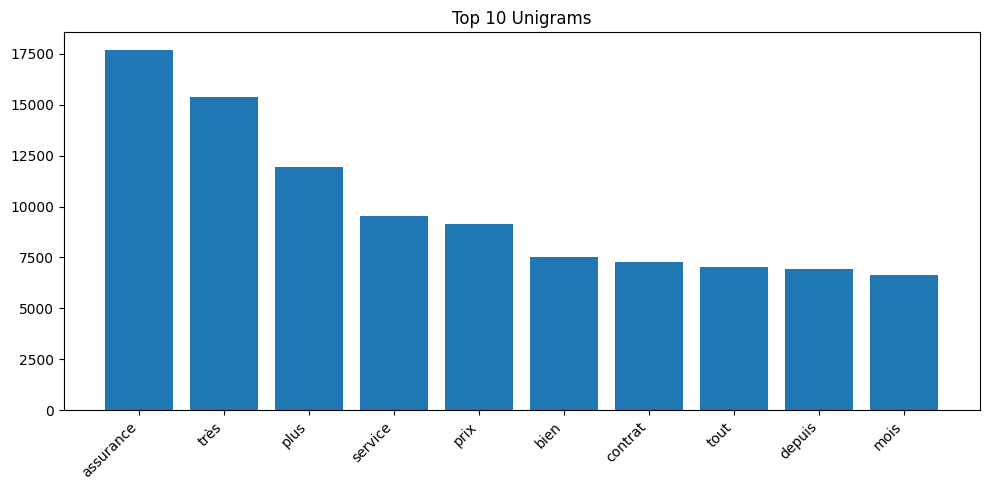

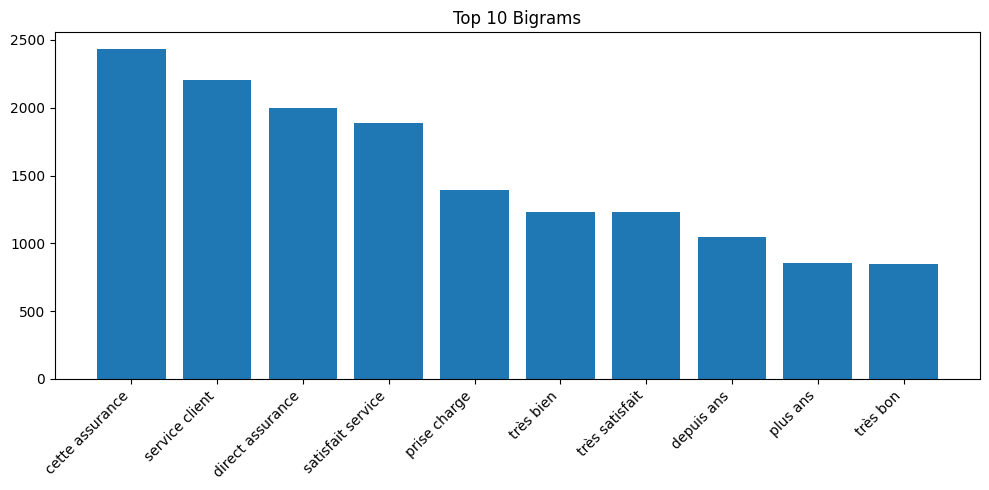

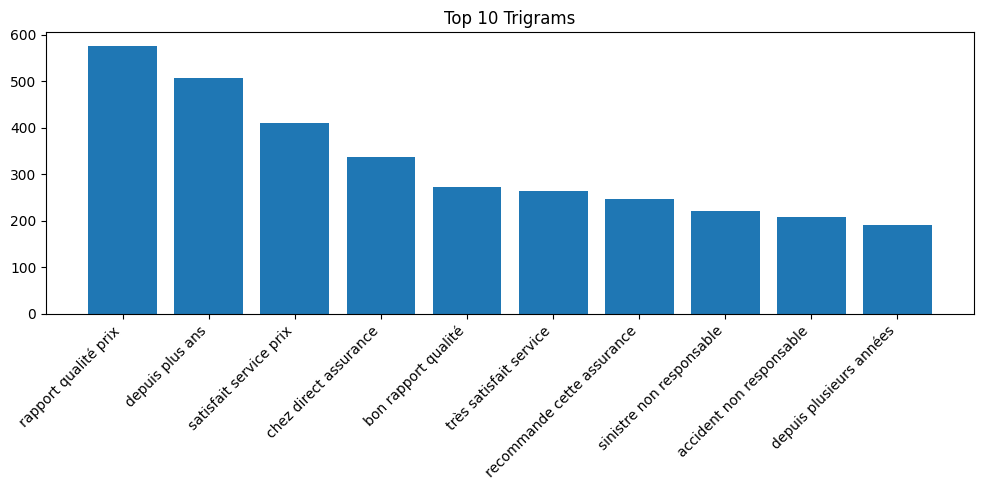

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams
import matplotlib.pyplot as plt
import pandas as pd

stop_words = set(stopwords.words("french"))

# Keep only valid strings
texts = all_reviews["avis_cor"].dropna().astype(str)

# Create token list
all_tokens = []
for text in texts:
    tokens = [
        w for w in text.split()
        if w not in stop_words and len(w) > 2 and w.isalpha()
    ]
    all_tokens.extend(tokens)

def plot_ngrams(tokens, n=1, top_k=10, title="Top n-grams"):
    if n == 1:
        common = Counter(tokens).most_common(top_k)
    else:
        n_grams = list(ngrams(tokens, n))
        common = Counter(n_grams).most_common(top_k)
        common = [(" ".join(k), v) for k, v in common]

    labels, counts = zip(*common)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_ngrams(all_tokens, n=1, title="Top 10 Unigrams")
plot_ngrams(all_tokens, n=2, title="Top 10 Bigrams")
plot_ngrams(all_tokens, n=3, title="Top 10 Trigrams")

### Interpretation of frequent words and n-grams

The unigram, bigram, and trigram analysis helps us understand the most common words and expressions used in the reviews. The most frequent terms show that customers often talk about insurance, service, price, and contracts. This suggests that these are some of the main topics in the dataset.

The trigram results are especially useful because they give more context than single words. For example, expressions like *rapport qualité prix* and *bon rapport qualité* show that many reviews discuss value for money. Other expressions such as *recommande cette assurance* suggest positive customer opinions, while terms like *sinistre non responsable* and *accident non responsable* show that claim-related situations are also important in the reviews.

Overall, this analysis gives a first idea of the main themes in the corpus. It will be useful for the next parts of the project, especially topic detection, sentiment analysis, and supervised learning.

In [ ]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.0 MB/s eta 0:00:00


##***Summary, Translation, and Generation***

In this part of the project, the reviews are transformed into cleaner and more usable text versions.
The goal here is to improve the quality of the dataset by creating corrected and standardized text columns, and when needed, translated versions of the reviews. This step makes the data easier to analyze and prepares it for the next NLP tasks such as topic detection, sentiment analysis, and supervised learning.

**Translation**

In [ ]:
from deep_translator import GoogleTranslator
import pandas as pd

def translate_to_english(text):
    if pd.isna(text) or str(text).strip() == "":
        return text
    try:
        return GoogleTranslator(source="fr", target="en").translate(str(text))
    except:
        return text

translated_subset = all_reviews.sample(100, random_state=42).copy()
translated_subset["avis_cor_en"] = translated_subset["avis_cor"].apply(translate_to_english)

In [ ]:
for _, row in translated_subset[["avis_cor", "avis_cor_en"]].head(20).iterrows():
    print("French corrected review:")
    print(row["avis_cor"])
    print("\nEnglish translation:")
    print(row["avis_cor_en"])
    print("\n" + "-"*80 + "\n")

French corrected review:
accident non responsable mais avec tiers non identifié résultat vous payez de franchise je fais annuler ma déclaration de sinistre et demande que soit pris en charge le changement du feu diurne car je ai pris l extension de bris de glace avec franchise quand même réponse pas possible sa fait parti du sinistre que nous ne prenons pas en charge résultat vous payer pour un avoir aucune garantie

English translation:
accident not responsible but with an unidentified third party result you pay excess I have my claim declaration canceled and request that the change of the daytime running light be covered because I took the extension of broken glass with excess still response not possible it is part of the loss that we do not take care of result you pay for a credit no guarantee

--------------------------------------------------------------------------------

French corrected review:
le service est simple de utilisation le service est rapide à mettre en oeuvre le ser

Because translating the full dataset row by row is time-consuming, translation was applied to a representative subset of the corrected reviews instead of the entire corpus. This approach still allows us to create an English version of the data for comparison and experimentation, while keeping the preprocessing pipeline efficient.

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
stop = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'[^\w\s]', '', text) # delete ponctuation
    text = re.sub(r'\d+', '', text) # numbers with no semantic values

    tokens = word_tokenize(text, language='english') # tokenization
    tokens = [t for t in tokens if t not in stop] # delete stopwords

    # lemmatisation
    doc = nlp(" ".join(tokens))
    tokens = [token.lemma_ for token in doc]

    return tokens

all_reviews['review_tokens'] = all_reviews['avis_en'].apply(clean_text)

In [ ]:
pd.reset_option('display.max_colwidth')
all_reviews.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_clean,review_tokens
0,4.0,croco47-108902,nouvelle adhérente et ayant été en contact ave...,Néoliane Santé,sante,train,2021-04-02,2021-04-01,New member and having been in contact with Pop...,nouvelle adhérente et ayant été en contact ave...,nouvelle adhérente et ayant été en contact ave...,"[new, member, contact, pope, completely, satis..."
1,1.0,dt-117016,"Service téléphonique lamentable, impossibilité...",Malakoff Humanis,prevoyance,train,2021-06-14,2021-06-01,"Latable telephone service, impossibility of ha...",service téléphonique lamentable impossibilité ...,service téléphonique lamentable impossibilité ...,"[latable, telephone, service, impossibility, a..."
2,5.0,william-g-130367,Je suis très satisfait de l'ensemble des prest...,GMF,auto,train,2021-08-31,2021-08-01,I am very satisfied with all the services offe...,je suis très satisfait de l ensemble des prest...,je suis très satisfait de l ensemble des prest...,"[satisfied, service, offer, gmf, customer, man..."
3,4.0,gilberte-c-138206,Je suis satisfaite le prix me convient très bi...,APRIL,sante,train,2021-10-25,2021-10-01,I am satisfied the price suits me very well I ...,je suis satisfaite le prix me convient très bi...,je suis satisfaite le prix me convient très bi...,"[satisfied, price, suit, well, know, april, th..."
4,4.0,mica-72266,"..l.... . Nickel pour l instant, pas de sin...",L'olivier Assurance,auto,train,2019-03-18,2019-03-01,"..I.... . Nickel for the moment, no sinister w...",l nickel pour l instant pas de sinistre on ver...,l nickel pour l instant pas de sinistre on ver...,"[nickel, moment, sinister, see, usel, home, re..."


In [ ]:
all_reviews.to_csv("/content/cleaned_dataset.csv", index=False)
print("File saved.")

File saved.


In [ ]:
from google.colab import files
files.download("/content/cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>